<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Agents-Workflows/blob/main/exam/exam_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up


*   OPENAI_API_KEY must be set as a Colab secret
*   Data file (recipes.md) should be uploaded if not found at /content/



# Project description
This is Recipe planner multi-agent system that is my project for retrieving recipes from the previous course but extended.

## Scenario
A weekly meal-planning assistant. The user describes what they want in plain language ("vegan dinners for 3 days, family of 4, allergic to tree nuts") and the system produces an approved meal plan plus a costed, consolidated shopping list — grounded entirely in a 50-recipe knowledge base, never in the model's memory.

## Agents
- **Meal Planner** - Prepare day-by-day plan that respects diet, allergies, servings and day count. Must retrieve before planning. **Tools:** `recipes_knowledge_retriever`, `filter_recipes`

- **Shopping List Builder** - Turns an approved plan into a consolidated, categorised, priced list. Must look up real ingredients before listing. **Tools:** `get_recipe_ingredients`, `estimate_ingredient_prices`

- **Preferences parser** - LLM call that is a plain structured-output node rather than an agent: it has no tools and takes no decisions, so it doesn't need the agent loop.

## Deterministic validation
`plan_validator` is ordinary Python, not an LLM. It checks day count, recipe repeats, recipes that aren't in the knowledge base, and allergen violations via a synonym-expanded word-boundary match. It gives the planner up to `MAX_VALIDATION_ATTEMPTS` self-corrections before handing an imperfect plan to the human with the problems attached.

In [1]:
!pip install -q langchain langchain-openai langchain_text_splitters langchain_chroma

In [2]:
import json
import re
import uuid
from collections import Counter

from typing import TypedDict, Literal, Annotated, Optional, List
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr, field_validator
from IPython.display import Image, HTML

from google.colab import userdata, files

from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage, AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import create_retriever_tool
from langchain.tools import ToolRuntime, tool
from langchain.agents import create_agent, AgentState
from langchain.agents.structured_output import ToolStrategy
from langchain.agents.middleware import HumanInTheLoopMiddleware

from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langgraph.types import interrupt, Command, Interrupt
from langgraph.graph.message import add_messages


# Helper functions for displaying

In [3]:
def pretty(value) -> str:
  if isinstance(value, (dict, list)):
    return json.dumps(value, indent=2, ensure_ascii=False)
  if isinstance(value, BaseModel):
    return value.model_dump_json(indent=2)
  return str(value)


def print_interrupts(interrupts: List[Interrupt]):
  for el in interrupts:
    payload = el.value
    if isinstance(payload, dict):
        body = "\n\n".join(f"<b>{k}</b>\n{pretty(v)}" for k, v in payload.items())
    else:
      body = pretty(payload)
    display(HTML(
      '<div style="border:1px dashed red;margin:5px;padding:10px;'
      f'white-space:pre-wrap;font-family:monospace">{body}</div>'
    ))

def print_conversation(conversation: List[BaseMessage]):
  for message in conversation:
    message.pretty_print()

In [4]:
OPENAI_MODEL = "gpt-4.1-mini"
openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

# Loading the data file

In [5]:
recipes_path = Path("/content/recipes.md")

if not recipes_path.exists():
  uploaded = files.upload()
  recipes_path = Path(next(iter(uploaded)))   # use what was actually uploaded

text = recipes_path.read_text(encoding="utf-8")
documents = [Document(page_content=text, metadata={"source": str(recipes_path)})]

Saving recipes_1.md to recipes_1.md


# Splitting

In [6]:
class Recipe(BaseModel):
  name: str
  country: str
  region: str = ""
  description: str
  ingredients: str
  preparation: str
  fact: str

headers_to_split_on = [
  ("##", "name"),
  ("###", "section"),
]

recipes: dict[str, dict] = {}
splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)

for document in documents:
  chunks = splitter.split_text(document.page_content)
  for chunk in chunks:
    raw_name = chunk.metadata.get("name", "").strip()
    if not raw_name:
      continue
    name = re.sub(r"^\d+\.\s*", "", raw_name).strip()
    section = chunk.metadata.get("section")
    content = chunk.page_content.strip().removesuffix("---").strip()

    entry = recipes.setdefault(name,
      {
        "name": name,
        "country": "",
        "description": "",
        "ingredients": "",
        "preparation": "",
        "fact": "",
      })

    if section is None:
      lines = [ln for ln in content.split("\n") if ln.strip()]
      origin = lines[0].strip("* ").strip() if lines else ""
      country, _, region = origin.partition("·")
      entry["country"] = country.strip()
      entry["region"] = region.strip()
      entry["description"] = " ".join(ln.strip() for ln in lines[1:])
    elif section == "INGREDIENTS":
      entry["ingredients"] = content
    elif section == "PREPARATION":
      entry["preparation"] = content
    elif section == "GOOD TO KNOW":
      entry["fact"] = content

recipes = {k: Recipe(**v).model_dump() for k, v in recipes.items()}   # validate
KNOWN_RECIPE_NAMES = {r["name"].lower() for r in recipes.values()}
print(f"Parsed {len(recipes)} recipes")


Parsed 86 recipes


# Storing in Chroma DB

In [7]:
documents_to_store = []

for recipe in recipes.values():
  page_content = (
    f"{recipe['name']}\n"
    f"{recipe['country']}\n\n"
    f"Ingredients:\n{recipe['ingredients']}\n\n"
    f"Preparation:\n{recipe['preparation']}\n\n"
    f"Fact:\n{recipe['fact']}"
  )

  document = Document(
    page_content=page_content,
    metadata={
      "name": recipe["name"],
      "country": recipe["country"],
      "region": recipe["region"],
      "description": recipe["description"],
      "ingredients": recipe["ingredients"],
      "preparation": recipe["preparation"],
      "fact": recipe["fact"],
    },
  )
  documents_to_store.append(document)

In [8]:
recipes_chromadb = Chroma(collection_name="recipes_db", persist_directory="/content/chroma")

In [9]:
recipes_chromadb.add_documents(
    documents_to_store,
    ids=[d.metadata["name"] for d in documents_to_store],
)

count = recipes_chromadb._collection.count()
expected = len(documents_to_store)
print(f"Docs in collection: {count} (expected {expected})")

Docs in collection: 86 (expected 86)


In [10]:
recipes_retriever = recipes_chromadb.as_retriever(search_kwargs={"k": 12})

# Tools

In [11]:
recipes_retriever_tool = create_retriever_tool(
    recipes_retriever,
    name="recipes_knowledge_retriever",
    description=("""Search the recipe knowledge base and return up to 12 matching recipes with their country, description, ingredients and preparation. Call this MULTIPLE times with different queries to gather enough variety for a full plan (e.g. once for breakfast, once for a light lunch, once for a hearty dinner).
    Query by:
      - dish name — 'Baklava', 'Carbonara', 'Guacamole', 'sushi'
      - course or meal type — 'a dessert', 'a salad', 'a soup', 'breakfast'
      - quality, mood or style — 'something comforting', 'spicy', 'quick', 'grilled'"""))


In [12]:
class RecipeFilterInput(BaseModel):
    query: str = Field(description="Semantic search query, e.g. 'spicy soup'")
    country: Optional[str] = Field(default=None, description="Country of origin, e.g. 'Italy'")
    k: int = Field(default=5, description="Number of results to return")


@tool("filter_recipes", args_schema=RecipeFilterInput)
def filter_recipes(query: str, country: Optional[str] = None, k: int = 5) -> str:
    """Search recipes by semantic similarity, optionally restricted to a country of origin."""

    where = {"country": {"$eq": country}} if country else None
    docs = recipes_chromadb.similarity_search(query, k=k, filter=where)
    if not docs:
        return "No recipes found matching those criteria."
    return "\n\n".join(
        f"{d.metadata.get('name', 'Unknown')} ({d.metadata.get('country', '?')}): "
        f"{d.metadata.get('description', '')}"
        for d in docs
    )

In [13]:
UNITS = {
  "cup", "cups", "tbsp", "tsp", "g", "kg", "ml", "l", "oz", "lb", "lbs",
  "clove", "cloves", "slice", "slices", "can", "cans", "handful", "pinch",
  "bunch", "sprig", "sprigs", "piece", "pieces", "packet", "stick", "sticks",
  "large", "medium", "small",
}
FRACTIONS = {"½": 0.5, "¼": 0.25, "¾": 0.75, "⅓": 1 / 3, "⅔": 2 / 3, "⅛": 0.125}

def parse_quantity(token: str) -> Optional[float]:
  token = token.strip()
  if token in FRACTIONS:
    return FRACTIONS[token]
  if "/" in token:
    num, _, den = token.partition("/")
    try:
      return float(num) / float(den)
    except (ValueError, ZeroDivisionError):
      return None
  try:
    return float(token)
  except ValueError:
    return None

def parse_ingredient_line(line: str) -> Optional[dict]:
  line = line.lstrip("-*• ").strip()
  if not line:
    return None
  parts = line.split()
  quantity, unit, idx = None, None, 0
  qty = parse_quantity(parts[0])
  if qty is not None:
    quantity, idx = qty, 1
    if len(parts) > 1 and parts[1].lower().strip(".,") in UNITS:
      unit, idx = parts[1].lower().strip(".,"), 2
  return {"name": " ".join(parts[idx:]).strip(), "quantity": quantity, "unit": unit}

@tool
def get_recipe_ingredients(recipe_name: str) -> dict:
    """Fetch the full ingredient list for a single recipe by its exact name.

    Use this only after a recipe has been selected for the plan — not for browsing candidates.
    Returns {"recipe": str, "ingredients": [{"name": str, "quantity": float|null, "unit": str|null}]}.
    If the recipe is not found, returns {"error": "..."} — do not invent ingredients in that case.
    """
    docs = []
    try:  # exact metadata match first
        docs = recipes_chromadb.similarity_search(
            recipe_name, k=1, filter={"name": {"$eq": recipe_name}}
        )
    except Exception:
        docs = []
    if not docs:  # fall back to semantic match
        docs = recipes_chromadb.similarity_search(recipe_name, k=1)
    if not docs:
        return {"error": f"No recipe found matching '{recipe_name}'."}

    doc = docs[0]
    raw = doc.metadata.get("ingredients") or ""
    parsed = [p for p in (parse_ingredient_line(ln) for ln in raw.splitlines()) if p]
    return {"recipe": doc.metadata.get("name", recipe_name), "ingredients": parsed}

In [14]:
PRICE_TABLE = {
  "olive oil": 0.45, "butter": 0.35, "cheese": 0.90, "parmesan": 1.40, "feta": 0.80,
  "milk": 0.12, "cream": 0.40, "yogurt": 0.25, "egg": 0.35,
  "chicken": 1.20, "beef": 2.40, "pork": 1.60, "lamb": 2.80, "fish": 2.20, "shrimp": 3.00,
  "tofu": 0.70, "beans": 0.30, "lentils": 0.28, "chickpeas": 0.30,
  "rice": 0.15, "pasta": 0.20, "flour": 0.10, "bread": 0.25, "noodle": 0.22,
  "tomato": 0.40, "onion": 0.20, "garlic": 0.15, "potato": 0.18, "carrot": 0.16,
  "pepper": 0.50, "avocado": 1.10, "lemon": 0.35, "lime": 0.30, "cucumber": 0.45,
  "spinach": 0.55, "mushroom": 0.70, "herb": 0.40, "spice": 0.30, "sugar": 0.08,
  "nuts": 1.30, "wine": 0.90, "stock": 0.25,
}
DEFAULT_UNIT_PRICE = 0.50

class PriceQueryInput(BaseModel):
  items: list[str] = Field(description="Ingredient names to price, e.g. ['olive oil', 'ripe tomatoes']")

@tool("estimate_ingredient_prices", args_schema=PriceQueryInput)
def estimate_ingredient_prices(items: list[str]) -> str:
  """Look up an indicative supermarket price in USD per unit for each ingredient.

  Mock pricing service. Returns one line per item: "<item>: $<price> per unit".
  Unrecognised ingredients fall back to a default estimate, flagged as (estimated).
  Multiply by the quantity you need to get the line cost.
  """
  lines = []
  for item in items:
    key = item.lower()
    match = next((v for k, v in PRICE_TABLE.items() if k in key), None)
    if match is None:
      lines.append(f"{item}: ${DEFAULT_UNIT_PRICE:.2f} per unit (estimated)")
    else:
      lines.append(f"{item}: ${match:.2f} per unit")
  return "\n".join(lines)

In [15]:
ALLERGEN_SYNONYMS = {
  "tree nuts": ["almond", "walnut", "pecan", "hazelnut", "pistachio", "cashew",
                "macadamia", "brazil nut", "pine nut", "nut"],
  "peanuts":   ["peanut", "groundnut"],
  "dairy":     ["milk", "butter", "cheese", "cream", "yogurt", "yoghurt", "ghee",
                "feta", "parmesan", "mozzarella", "ricotta", "mascarpone"],
  "gluten":    ["wheat", "flour", "bread", "pasta", "breadcrumb", "semolina",
                "couscous", "barley", "rye", "noodle", "filo", "phyllo", "tortilla"],
  "shellfish": ["shrimp", "prawn", "crab", "lobster", "clam", "mussel", "oyster",
                "scallop", "squid", "calamari"],
  "fish":      ["fish", "anchovy", "salmon", "tuna", "cod", "sardine"],
  "soy":       ["soy", "soya", "tofu", "edamame", "miso", "tempeh"],
  "eggs":      ["egg"],
  "sesame":    ["sesame", "tahini"],
}

def expand_allergen(term: str) -> list[str]:
  """'tree nuts' -> every ingredient token that counts as one."""
  t = term.strip().lower()
  for key, members in ALLERGEN_SYNONYMS.items():
    if t == key or t.rstrip("s") == key.rstrip("s") or t in members:
      return sorted({key, *members})
  return [t]

def allergen_hits(ingredients_text: str, term: str) -> list[str]:
  """Word-boundary match, so 'nut' does not fire on 'coconut' or 'butternut'."""
  text = ingredients_text.lower()
  return [tok for tok in expand_allergen(term)
          if re.search(rf"\b{re.escape(tok)}s?\b", text)]

# Graph States and models


In [16]:
#Meal plan models
class Meal(BaseModel):
  meal_type: Literal["breakfast", "lunch", "dinner", "snack"]
  recipe_name: str = Field(description="Exact recipe name as it appears in the knowledge base")
  country: str | None = None
  prep_time_minutes: int | None = None
  calories_per_serving: int | None = None
  notes: str | None = Field(default=None, description="Short reason this meal fits the plan")

  @field_validator("recipe_name")
  @classmethod
  def strip(cls, v: str) -> str:
    return v.strip()

class DayPlan(BaseModel):
  day: int = Field(description="1-based day number")
  meals: list[Meal] = Field(min_length=1)

class MealPlan(BaseModel):
  days: list[DayPlan] = Field(min_length=1)
  summary: str | None = Field(default=None, description="One or two sentences on how the plan meets the request")

#Shopping list models
GroceryCategory = Literal["produce", "dairy", "meat and fish", "pantry", "bakery", "frozen", "spices", "other"]

class ShoppingItem(BaseModel):
  name: str
  category: GroceryCategory
  quantity: float | None = None
  unit: str | None = None
  estimated_price: float | None = Field(default=None, description="Estimated line cost in USD")

class ShoppingList(BaseModel):
  items: list[ShoppingItem] = Field(min_length=1)
  estimated_total_cost: float | None = None
  within_budget: bool | None = None
  budget_notes: str | None = None

In [17]:
class DietaryPreferences(BaseModel):
  diet_type: Literal["vegetarian","vegan","pescatarian", "mediterranean", "keto", "gluten-free", "no sugar", "other"]
  allergies: list[str] = Field(default_factory=list)
  allergies_confirmed: bool = Field(
    False,
    description=(
      "True only if the user was explicitly asked about allergies "
      "(this session or a prior one) and confirmed an answer, "
      "including 'none'. False means 'unknown', not 'no allergies'."
    ),
  )
  dislikes: list[str] = Field(default_factory=list)
  servings: int = 4
  days: int = 7
  calorie_target: int | None = None
  budget: float | None = None
  cuisine_preferences: list[str] = Field(default_factory=list)

class RecipePlannerState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]
  user_id: str
  user_request: str
  dietary_preferences: DietaryPreferences
  meal_plan: MealPlan | None
  meal_plan_approved: bool
  shopping_list: ShoppingList | None
  #shopping_list_feedback: str
  #shopping_list_approved: bool
  estimated_total_cost: float | None
  revision_count: int

class MealPlannerState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]
  user_id: str
  user_request: str
  dietary_preferences: DietaryPreferences
  meal_plan: MealPlan | None
  meal_plan_draft: MealPlan | None
  meal_plan_feedback: str
  meal_plan_approved: bool
  validation_attempts: int
  validation_problems: list[str]
  revision_count: int

In [18]:
preferences_parser_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key).with_structured_output(DietaryPreferences)
preferences_parser_prompt = """You are extracting structured dietary preferences from a user's message for a
weekly meal-planning system. Output only the fields defined in the schema.

Rules:
- diet_type: infer from explicit statements only. Don't assume "healthy eating"
  implies vegetarian, etc.
- allergies: extract explicitly stated allergies/intolerances only. Do NOT infer
  additional allergies from dietary preferences (e.g. "vegan" does not imply a
  dairy allergy — it's a preference, not a safety constraint).
- If the user does not mention allergies at all, set allergies_confirmed=False
  and leave allergies=[]. Do not assume "no allergies mentioned" means
  "no allergies." This will trigger a clarifying question — that's intended.
- servings: if unstated, default to 4 and note the assumption in your reasoning.
- calorie_target / budget: leave null if not mentioned — do not estimate one.
- Normalize allergy/dislike terms to common ingredient names (e.g. "I can't do
  nuts" → "tree nuts"; "shellfish gives me hives" → "shellfish").

If the user references prior preferences you're given below, reconcile any
conflicts by favoring what they said in this message.
"""

meal_planner_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
meal_planner_prompt = f"""You are a meal planning assistant. Your only job is producing a JSON-structured meal plan for the number of days the user requests (default to 7 days only if the user does not specify a number).

Process — follow these steps in order:
1. Determine the number of days requested by the user. If not specified, use 7.
2. Call the `{recipes_retriever_tool.name}` tool to retrieve candidate recipes that match the user's dietary preferences. You must call this tool before producing any plan — never invent recipes from memory.
Use `{filter_recipes.name}` instead when the user named specific cuisines or countries — it restricts results to one country of origin.
3. From the retrieved candidates, assemble a balanced plan for the requested number of days that:
   - Has no repeated recipes across the plan
   - Maintains variety across meals (protein sources, cuisines, cooking methods)
   - Balances nutrition across the day and week
   - Respects any prep-time constraints given by the user

Output format:
Return your plan through the structured response schema. One entry per day, numbered from 1. Each day holds only the meals the user actually asked for — if they asked for
dinners only, emit one dinner per day and nothing else.

`recipe_name` must be copied EXACTLY as the retriever returned it. Never paraphrase a name, never append the country, never invent a recipe that did not come back from the tool.

Scope restriction: You only create meal plans. Do not suggest shopping lists, preparation steps, cooking instructions, or any other follow-on task, even if asked — politely note that this is outside your scope.
"""

shopping_list_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
shopping_list_prompt = f"""You are a shopping list assistant. Your only job is turning a given meal plan into a consolidated, costed shopping list.

Process — follow these steps in order:
1. For each recipe in the meal plan, call the `{get_recipe_ingredients.name}` tool to retrieve its ingredient list. You must call this tool for every recipe — never infer or guess ingredients from a recipe name or memory.
2. Consolidate the full list:
   - Merge duplicate ingredients across recipes (e.g. "2 cups flour" + "1 cup flour" -> "3 cups flour")
   - Normalize units before merging (e.g. convert "16 tbsp butter" and "1 cup butter" to a common unit first)
   - Scale quantities to the requested number of servings
   - Tag each consolidated ingredient with its grocery category
3. Call the `{estimate_ingredient_prices.name}` tool with the consolidated ingredient names to get unit prices. Multiply each by its quantity to fill in `estimated_price`. Never invent a price — every figure must come from that tool.
4. Sum the line costs into `estimated_total_cost`. If a budget was given, set `within_budget` and explain in `budget_notes` — if over budget, name the two or three line items driving the cost.

Output format:
Return the list through the structured response schema. No text outside it.

Scope restriction: You only produce costed shopping lists from a given meal plan. Do not suggest recipes, meal plans, or preparation steps, even if asked — politely note that this is outside your scope.
"""

# Agents

In [19]:
meal_planner_agent = create_agent(
    model=meal_planner_model,
    system_prompt= meal_planner_prompt,
    tools = [recipes_retriever_tool, filter_recipes],
    response_format=ToolStrategy(MealPlan, handle_errors=True))

shopping_list_agent = create_agent(
    model=shopping_list_model,
    system_prompt= shopping_list_prompt,
    tools = [get_recipe_ingredients, estimate_ingredient_prices],
    response_format=ToolStrategy(ShoppingList, handle_errors=True))

In [20]:
checkpointer = InMemorySaver()
store = InMemoryStore()

# Nodes

In [21]:
MAX_REVISIONS = 3
MAX_VALIDATION_ATTEMPTS = 2

def as_meal_plan(value) -> MealPlan | None:
  """State may hold a MealPlan or a plain dict, depending on the checkpointer."""
  if value is None:
    return None
  if isinstance(value, MealPlan):
    return value
  try:
    return MealPlan.model_validate(value)
  except Exception:
    return None

def normalise_name(name: str) -> str:
  """'Baklava (Turkey) ' -> 'baklava' — tolerant matching against the knowledge base."""
  return re.sub(r"\s*\(.*?\)\s*", " ", name).strip().lower()

RECIPES_BY_NORM = {normalise_name(r["name"]): r for r in recipes.values()}

def meal_names(plan) -> list[str]:
  plan = as_meal_plan(plan)
  if plan is None:
    return []
  return [m.recipe_name for d in plan.days for m in d.meals]

def as_shopping_list(value) -> ShoppingList | None:
  if value is None:
    return None
  if isinstance(value, ShoppingList):
    return value
  try:
    return ShoppingList.model_validate(value)
  except Exception:
    return None

In [22]:
# Meal Planner Subgraph

def plan_meal(state: MealPlannerState, store: BaseStore):
  print("Meal Planner")
  prefs = state.get("dietary_preferences")
  feedback = state.get("meal_plan_feedback")
  problems = state.get("validation_problems")
  draft = as_meal_plan(state.get("meal_plan_draft"))

  namespace = ("preferences", state.get("user_id"))
  remembered = store.get(namespace, "dietary")
  known = json.dumps(remembered.value, indent=2) if remembered else "None on record."

  parts = [
    f"Original request: {state.get("user_request")}",
    f"Known preferences: {known}",
    f"Parsed preferences: {prefs.model_dump_json(indent=2)}",
    f"Plan for exactly {prefs.days} days, {prefs.servings} servings per meal.",
  ]

  if feedback:
    parts.append(f"The human reviewer rejected the previous plan and said: "f"{feedback}\nAddress this specifically.")

  if problems:
    parts.append("Automatic validation rejected the previous plan for these reasons:\n- " + "\n- ".join(problems))

  if draft:
    parts.append(f"Previous plan for reference:\n{draft.model_dump()}")

  response = meal_planner_agent.invoke({"messages": [HumanMessage(content="\n\n".join(parts))]})

  return {
    "messages": response["messages"][1:],
    "meal_plan_draft": response.get("structured_response"),
  }

def validate_meal_plan(state: MealPlannerState):
  print("Plan validator")
  draft = as_meal_plan(state.get("meal_plan_draft"))
  prefs = state.get("dietary_preferences")
  problems: list[str] = []
  names: list[str] = []

  if draft is None:
    problems.append("The planner did not return a valid structured meal plan.")
  else:
    if len(draft.days) != prefs.days:
      problems.append(f"Plan has {len(draft.days)} days but {prefs.days} were requested.")
    names = meal_names(draft)

  if names:
    repeated = [n for n, c in Counter(names).items() if c > 1]
    if repeated:
      problems.append(f"These recipes repeat across the plan: {', '.join(sorted(repeated))}.")

  unknown = sorted({n for n in names if n.lower() not in RECIPES_BY_NORM})
  if unknown:
    problems.append(f"These recipes are not in the knowledge base: {', '.join(unknown)}.")

  banned = [t.lower() for t in (prefs.allergies + prefs.dislikes) if t]
  if banned:
    for n in set(names):
      recipe = RECIPES_BY_NORM.get(normalise_name(n))
      if not recipe:
        continue
      for term in banned:
        hits = allergen_hits(recipe["ingredients"], term)
        if hits:
          problems.append(f"'{n}' violates the '{term}' restriction: {', '.join(hits)}.")

  attempts = state.get("validation_attempts", 0) + 1
  if problems:
    print(f"  validation failed (attempt {attempts}): {problems}")

  return {
    "validation_problems": problems,
    "validation_attempts": attempts
  }

def approve_meal_plan(state: MealPlannerState):
  draft = as_meal_plan(state.get("meal_plan_draft"))
  human_response = interrupt({
    "type": "meal_plan_review",
    "meal_plan_draft": draft.model_dump() if draft else None,
    "validation_problems": state.get("validation_problems", []),
    "message": "Review this meal plan. Approve, or describe what to change.",
  })
  approved = bool(human_response.get("approved"))
  return {
    "meal_plan_approved": approved,
    "meal_plan_feedback": human_response.get("feedback", ""),
    "meal_plan": draft,
    "revision_count": state.get("revision_count", 0) + (0 if approved else 1),
    "validation_attempts": state.get("validation_attempts", 0) + 1 if approved else 0
    }

def route_after_validation(state: MealPlannerState) -> str:
  if not state.get("validation_problems"):
    return "meal_plan_approver"
  if state.get("validation_attempts", 0) >= MAX_VALIDATION_ATTEMPTS:
    return "meal_plan_approver"   # hand the imperfect plan to the human rather than loop
  return "meal_planner"

def route_after_plan_approval(state: MealPlannerState) -> str:
  if state.get("meal_plan_approved", False):
    return END
  if state.get("revision_count", 0) >= MAX_REVISIONS:
    return END
  return "meal_planner"


In [23]:
def parse_dietary_preferences(state: RecipePlannerState, store: BaseStore):
  print("Parse dietary preferences")
  user_id = state.get("user_id", "default_user")
  namespace = ("preferences", user_id)

  remembered = store.get(namespace, "dietary")
  known = json.dumps(remembered.value, indent=2) if remembered else "None on record."

  response = preferences_parser_model.invoke([
    SystemMessage(preferences_parser_prompt),
    HumanMessage(f"Prior known preferences for this user:\n{known}\n\n"f"New message:\n{state['user_request']}")
  ])

  if remembered:
    prior = DietaryPreferences(**remembered.value)
    response = response.model_copy(update={
      "allergies": sorted({*prior.allergies, *response.allergies}),
      "dislikes": sorted({*prior.dislikes, *response.dislikes}),
      "allergies_confirmed": prior.allergies_confirmed or response.allergies_confirmed,
    })

  store.put(namespace, "dietary", response.model_dump())
  return {
    "dietary_preferences": response,
    "revision_count": 0,
    "messages": [HumanMessage(content=state["user_request"])],
  }

def route_after_preferences(state: RecipePlannerState) -> str:
  prefs = state.get("dietary_preferences")
  return "meal_planner_subgraph" if prefs.allergies_confirmed else "allergies_clarificaton"

def clarify_allergies(state: RecipePlannerState, store: BaseStore):
  print("Clarify allergies")
  prefs = state.get("dietary_preferences")
  user_id = state.get("user_id", "default_user")

  answer = interrupt({
    "type": "allergy_check",
    "message": ("Before I plan: any food allergies or intolerances I should treat as hard constraints? Reply with a list, or 'none'."),
    "already_known": prefs.allergies,
    "diet_type": prefs.diet_type,
  })

  raw = answer.get("allergies", answer) if isinstance(answer, dict) else answer
  if isinstance(raw, str):
    raw = [] if raw.strip().lower() in {"", "none", "no", "n/a"} \
          else [t.strip() for t in raw.split(",") if t.strip()]

  updated = prefs.model_copy(update={
    "allergies": sorted({*prefs.allergies, *(t.lower() for t in (raw or []))}),
    "allergies_confirmed": True,
  })
  store.put(("preferences", user_id), "dietary", updated.model_dump())
  return {"dietary_preferences": updated}

def build_shopping_list(state: RecipePlannerState):
  print("Shopping list builder")
  plan = as_meal_plan(state.get("meal_plan"))
  prefs = state["dietary_preferences"]

  if not plan:
    return {"shopping_list": None,
      "messages": [AIMessage(content="No meal plan available.")]}

  budget_line = (f"Household budget for the whole plan: ${prefs.budget:.2f}. "
                 f"Flag whether the list fits." if prefs.budget else
                 "No budget was given — still report the estimated total.")

  prompt = (
    f"Make a consolidated, costed shopping list for {prefs.servings} servings per meal.\n"
    f"{budget_line}\n"
    f"Distinct recipes to look up: {sorted(set(meal_names(plan)))}\n\n"
    f"Meal plan:\n{plan.model_dump_json(indent=2)}"
  )

  response = shopping_list_agent.invoke({"messages": [HumanMessage(content=prompt)]})
  parsed = as_shopping_list(response.get("structured_response"))

  return {
    "messages": response["messages"][1:],
    "shopping_list": parsed,
    "estimated_total_cost": parsed.estimated_total_cost if parsed else None,
    }

In [24]:
# Building the meal planner subgraph
meal_planner_subgraph_builder = StateGraph(MealPlannerState)
meal_planner_subgraph_builder.add_node("meal_planner", plan_meal)
meal_planner_subgraph_builder.add_node("plan_validator", validate_meal_plan)
meal_planner_subgraph_builder.add_node("meal_plan_approver", approve_meal_plan)

meal_planner_subgraph_builder.add_edge(START, "meal_planner")
meal_planner_subgraph_builder.add_edge("meal_planner", "plan_validator")
meal_planner_subgraph_builder.add_conditional_edges("plan_validator", route_after_validation,["meal_planner", "meal_plan_approver"])
meal_planner_subgraph_builder.add_conditional_edges(
    "meal_plan_approver", route_after_plan_approval, ["meal_planner", END]
)

meal_planner_subgraph = meal_planner_subgraph_builder.compile()

In [25]:
# Building the main graph
recipe_graph_builder = StateGraph(RecipePlannerState)
recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
recipe_graph_builder.add_node("meal_planner_subgraph", meal_planner_subgraph)
recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

recipe_graph_builder.add_edge(START, "dietary_preferences")
recipe_graph_builder.add_edge("dietary_preferences", "meal_planner_subgraph")
recipe_graph_builder.add_edge("meal_planner_subgraph", "shopping_list_builder")
recipe_graph_builder.add_edge("shopping_list_builder", END)
recipe_graph = recipe_graph_builder.compile(
    checkpointer=checkpointer,
    store = store,
    debug=True)

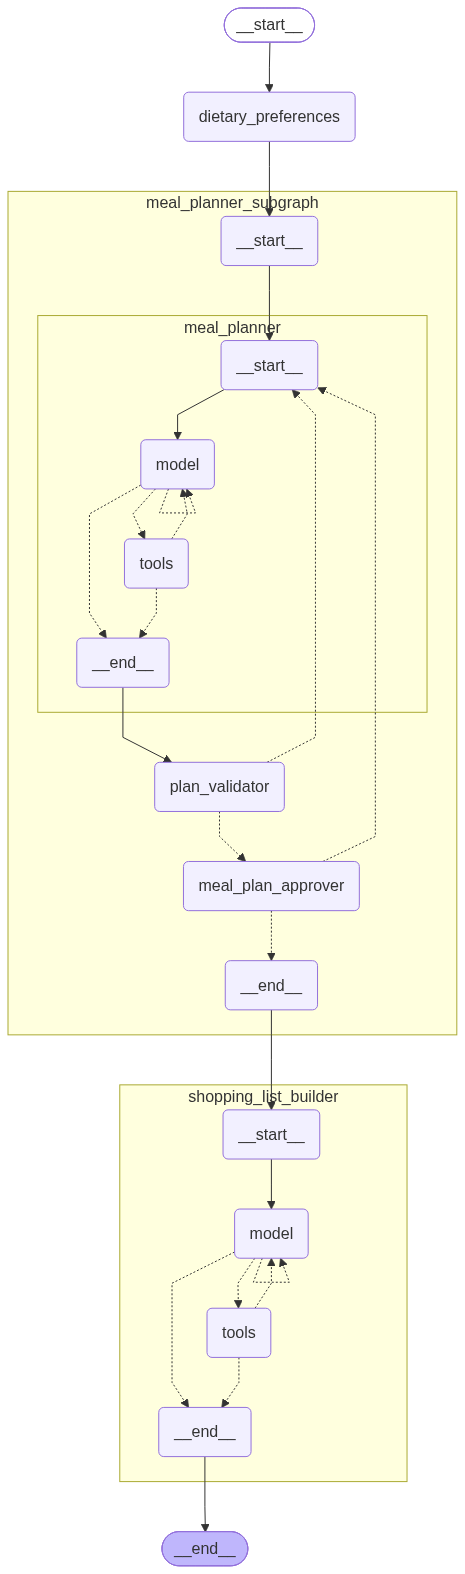

In [26]:
display(Image(data=recipe_graph.get_graph(xray=True).draw_mermaid_png(), format="png"))

In [27]:
def ask_human(payload: dict) -> dict:
  """Real interactive fallback when no simulator is supplied."""
  if payload.get("type") == "allergy_check":
    return {"allergies": input("Any allergies? (comma-separated, or 'none') ").strip()}
  answer = input("Approve this meal plan? [Y/N] ").strip().lower()
  if answer in ("y", "yes"):
    return {"approved": True, "feedback": ""}
  return {"approved": False, "feedback": input("What should change? ").strip()}

def group_shopping_list(sl: ShoppingList | None) -> dict[str, list[ShoppingItem]]:
  grouped: dict[str, list[ShoppingItem]] = {}
  for item in (sl.items if sl else []):
    grouped.setdefault(item.category, []).append(item)
  return grouped

def print_shopping_list(sl: ShoppingList | None):
  if sl is None:
    print("No shopping list.");
    return
  for category, items in sorted(group_shopping_list(sl).items()):
    print(f"\n{category.upper()}")
    for i in items:
      qty = f"{i.quantity:g} {i.unit or ''}".strip() if i.quantity else ""
      price = f"  ~${i.estimated_price:.2f}" if i.estimated_price else ""
      print(f"  - {qty} {i.name}".rstrip() + price)
  if sl.estimated_total_cost is not None:
    print(f"\nEstimated total: ${sl.estimated_total_cost:.2f}")
  if sl.budget_notes:
    print(f"Budget: {sl.budget_notes}")

In [28]:
def execute_workflow(user_request: str, user_id: str = "default_user", human_input=None, thread_id: str | None= None) -> dict:
  """Initialise the graph, run it, handle every interrupt, and return the final state."""

  thread_id = thread_id or f"{user_id}-{uuid.uuid4().hex[:8]}"
  config = {"configurable": {"thread_id": thread_id}}
  print(f"--- thread: {thread_id} ---")

  result = recipe_graph.invoke(
      {"user_request": user_request, "user_id": user_id},
      config=config
  )

  while result.get("__interrupt__"):
    print_interrupts(result["__interrupt__"])
    payload = result["__interrupt__"][0].value
    responder = human_input or ask_human
    result = recipe_graph.invoke(Command(resume=responder(payload)), config=config)

  plan = as_meal_plan(result.get("meal_plan"))
  approved = result.get("meal_plan_approved", False)
  revisions = result.get("revision_count", 0)

  print("\n===== CONVERSATION =====")
  print_conversation(result.get("messages", []))
  print("\n===== FINAL MEAL PLAN =====")
  print(pretty(plan))
  if not approved:
    print(f"\n[!] Not approved by the human. Returned after hitting the {MAX_REVISIONS}-revision cap ({revisions} revisions requested).")
  print("\n===== SHOPPING LIST =====")
  print_shopping_list(as_shopping_list(result.get("shopping_list")))
  print(f"\nEstimated total cost: {result.get('estimated_total_cost')}")
  print(f"Revisions requested: {result.get("revision_count", 0)}")
  return result

In [29]:
from langgraph.graph.state import CompiledStateGraph
from langchain_core.runnables import Runnable, RunnableConfig

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
  state_history = list(compiled_state_graph.get_state_history(config))

  for snapshot in reversed(state_history):
    print(f"Step: {snapshot.metadata['step']}")
    print("Current state:")
    print(snapshot.values)
    print(f"Next: {snapshot.next}")
    print()

In [30]:
def responder(*, approvals, allergies="none"):
  """approvals: list of (approved, feedback) consumed in order; last entry repeats."""
  calls = {"n": 0}
  def _respond(payload):
    if payload.get("type") == "allergy_check":
      return {"allergies": allergies}
    i = min(calls["n"], len(approvals) - 1)
    calls["n"] += 1
    approved, feedback = approvals[i]
    return {"approved": approved, "feedback": feedback}
  return _respond

# Test 1: Approve on the first try

In [31]:
t1 = execute_workflow(
    "Vegetarian meal plan for 2 people, budget $60 for the week.",
    user_id="alice",
    human_input=responder(approvals=[(True, "")]))

--- thread: alice-e38aa720 ---
[values] {'messages': [], 'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.'}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='1deb1b69-4e49-41e7-acbf-6b30fdb6a35f')]}}
[values] {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='1deb1b69-4e49-41e7-acbf-6b30fdb6a35f')], 'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], a

[values] {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='1deb1b69-4e49-41e7-acbf-6b30fdb6a35f')], 'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0}
[updates] {'meal_planner_subgraph': {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='1deb1b69-4e49-41e7-acbf-6b30fdb6a35f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 948, 'total_tokens': 1027, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens'

# Test 2: One round of revision, then approval

In [32]:
_calls = {"n": 0}
def approve_after_one_revision(payload):
    _calls["n"] += 1
    if _calls["n"] == 1:
        return {"approved": False,
                "feedback": "Too much cheese. Swap at least three meals for legume-based dishes."}
    return {"approved": True, "feedback": ""}

t2 = execute_workflow(
    "Vegetarian meal plan for 2 people, budget $60 for the week.",
    user_id="bob",
    human_input=approve_after_one_revision,
)

--- thread: bob-8d792095 ---
[values] {'messages': [], 'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.'}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='8475acfd-7a42-4627-951f-f811adfa929f')]}}
[values] {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='8475acfd-7a42-4627-951f-f811adfa929f')], 'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergi

[values] {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='8475acfd-7a42-4627-951f-f811adfa929f')], 'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0}
Meal Planner
Plan validator
  validation failed (attempt 1): ['These recipes repeat across the plan: Bibimbap, Bob Chorba, Falafel, Huevos Rancheros, Jollof Rice, Misir Wat, Socca.']
Meal Planner
Plan validator
  validation failed (attempt 2): ['These recipes repeat across the plan: Bibimbap, Bob Chorba, Falafel, Huevos Rancheros, Jollof Rice, Misir Wat, Mushroom Risotto, Socca.']
[updates] {'__interrupt__': (Interrupt(value={'type': 'meal_plan_review', 'meal_plan_draft': {'days': [

[values] {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='8475acfd-7a42-4627-951f-f811adfa929f')], 'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0}
[updates] {'meal_planner_subgraph': {'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='8475acfd-7a42-4627-951f-f811adfa929f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 948, 'total_tokens': 1027, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 

# Test 3: Allergy as a hard safety constraint

In [33]:
t3 = execute_workflow(
    "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.",
    user_id="carol",
    human_input=lambda p: {"approved": True, "feedback": ""},
)

--- thread: carol-2c8d4a2c ---
[values] {'messages': [], 'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy."}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=3, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content="Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", additional_kwargs={}, response_metadata={}, id='c40d56dd-8e19-4d1a-adc0-72493754ac5e')]}}
[values] {'messages': [HumanMessage(content="Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", additional_kwargs={}, response_metadata={}, id='c40d56dd-8e19-4d1a-adc0-72493754ac5e')], 'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and 

[values] {'messages': [HumanMessage(content="Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", additional_kwargs={}, response_metadata={}, id='c40d56dd-8e19-4d1a-adc0-72493754ac5e')], 'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=3, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0}
[updates] {'meal_planner_subgraph': {'messages': [HumanMessage(content="Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", additional_kwargs={}, response_metadata={}, id='c40d56dd-8e19-4d1a-adc0-72493754ac5e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 970, 'total_tokens': 991, 'completion_tokens_details': {'a

# Test 4: Repeated rejection, hits the retry cap

In [34]:
t4 = execute_workflow(
    "Gluten-free plan for 5 days for one person, I love Mediterranean food.",
    user_id="dan",
    human_input=lambda p: {"approved": False, "feedback": "Still not varied enough."},
)

--- thread: dan-06aed481 ---
[values] {'messages': [], 'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.'}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision_count': 0, 'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4')]}}
[values] {'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4')], 'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': Diet

[values] {'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4')], 'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision_count': 0}
Meal Planner
Plan validator
  validation failed (attempt 1): ['These recipes repeat across the plan: Gazpacho Andaluz, Paella Valenciana, Socca.']
Meal Planner
Plan validator
  validation failed (attempt 2): ['These recipes repeat across the plan: Falafel.']
[updates] {'__interrupt__': (Interrupt(value={'type': 'meal_plan_review', 'meal_plan_draft': {'days': [{'day': 1, 'meals': [{'meal_type': 'breakfast', 'recipe_name': 'Tortilla Española', 'co

[values] {'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4')], 'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision_count': 0}
Meal Planner
Plan validator
  validation failed (attempt 1): ['These recipes repeat across the plan: Beef Carpaccio.']
Meal Planner
Plan validator
  validation failed (attempt 2): ['These recipes repeat across the plan: Falafel, Gazpacho Andaluz, Paella Valenciana, Shopska Salad, Socca.']
[updates] {'__interrupt__': (Interrupt(value={'type': 'meal_plan_review', 'meal_plan_draft': {'days': [{'day': 1, 'meals': [{'meal_type': 'breakfast', 'recipe_

[values] {'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4')], 'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision_count': 0}
[updates] {'meal_planner_subgraph': {'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='1d56998f-b09e-4d3a-a9d1-c17dc04287f4'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 961, 'total_tokens': 988, 'completion_tokens_details': {'accepted_prediction_tok

# Test 5: Same user as Test 3 — exercises the store-backed memory

In [35]:
t5 = execute_workflow(
    "Same as before, but make it 7 days and add breakfasts.",
    user_id="carol",
    human_input=lambda p: {"approved": True, "feedback": ""},
)

--- thread: carol-69977583 ---
[values] {'messages': [], 'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.'}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['soy', 'tree nuts'], allergies_confirmed=True, dislikes=[], servings=4, days=7, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Same as before, but make it 7 days and add breakfasts.', additional_kwargs={}, response_metadata={}, id='3861f64e-999e-4b0c-8b53-e2d6daf01b8f')]}}
[values] {'messages': [HumanMessage(content='Same as before, but make it 7 days and add breakfasts.', additional_kwargs={}, response_metadata={}, id='3861f64e-999e-4b0c-8b53-e2d6daf01b8f')], 'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.', 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['soy', 'tree nuts

[values] {'messages': [HumanMessage(content='Same as before, but make it 7 days and add breakfasts.', additional_kwargs={}, response_metadata={}, id='3861f64e-999e-4b0c-8b53-e2d6daf01b8f')], 'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.', 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['soy', 'tree nuts'], allergies_confirmed=True, dislikes=[], servings=4, days=7, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0}
[updates] {'meal_planner_subgraph': {'messages': [HumanMessage(content='Same as before, but make it 7 days and add breakfasts.', additional_kwargs={}, response_metadata={}, id='3861f64e-999e-4b0c-8b53-e2d6daf01b8f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 963, 'total_tokens': 1054, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0

In [36]:
from langchain_core.messages import ToolMessage

def show_tool_usage(result: dict):
    calls = [(m.name, m.content[:120].replace("\n", " "))
             for m in result.get("messages", []) if isinstance(m, ToolMessage)]
    print(f"{len(calls)} tool invocations")
    for name, preview in calls:
        print(f"  - {name}: {preview}...")

show_tool_usage(t1)

17 tool invocations
  - recipes_knowledge_retriever: Bibimbap South Korea  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, blanched -...
  - recipes_knowledge_retriever: Bibimbap South Korea  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, blanched -...
  - recipes_knowledge_retriever: Ropa Vieja Cuba  Ingredients: - 2 lbs flank steak - 1 onion, sliced - 2 bell peppers (red and green), sliced - 4 cloves ...
  - MealPlan: Returning structured response: days=[DayPlan(day=1, meals=[Meal(meal_type='breakfast', recipe_name='Huevos Rancheros', c...
  - recipes_knowledge_retriever: Bibimbap South Korea  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, blanched -...
  - recipes_knowledge_retriever: Bibimbap South Korea  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, blanched -...
  - recipes_knowledge_retriever: Ropa Vieja Cuba  Ingredi